### Experimental comparison of the object numbers obtained from the IA web collection and the Historical Data Dumps of the Rijksmuseum

There is a code in the 02_analysis.ipynb that describes process of object numbers extraction from the URL-strings related to the Rijksmuseum website captured by the Internet Archive. This dataset has been compared with the dataset from the Rijksmuseum 202001-rma-csv-collection.csv (Historical Data Dumps, Rijksmuseum Data Services, https://data.rijksmuseum.nl/docs/data-dumps/historical-dumps)

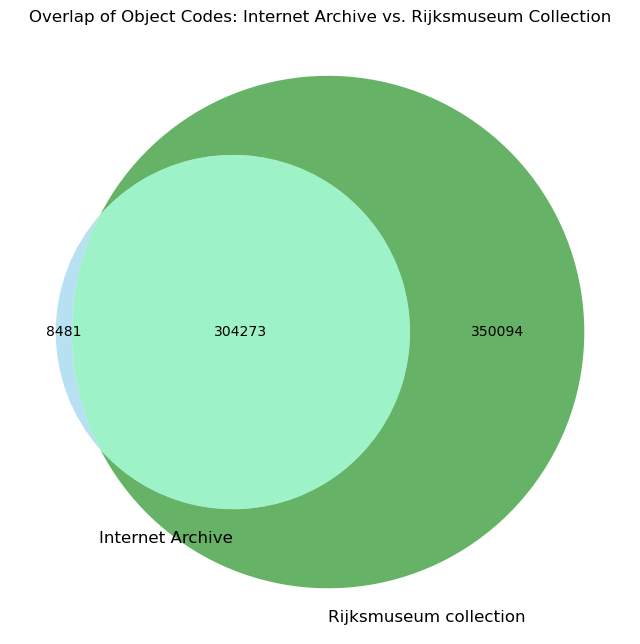

In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import os

# Define base data folder
base_dir = r'data'

# Input files
file_ia = os.path.join(base_dir, 'object_numbers_IA.csv')
file_rma = os.path.join(base_dir, '202001-rma-csv-collection.csv')

# Output folders
output_dir = base_dir
image_dir = r'images'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

# Regex pattern for Rijksmuseum object codes (e.g. SK-A-1234, RP-P-OB-12.345)
code_pattern = re.compile(r'\b(?:[A-Z0-9]+-){1,}[A-Z0-9.]+\b')

# Function to extract a code from a free-text/url string
def extract_code(value):
    match = code_pattern.search(str(value))
    return match.group(0) if match else None

# Candidate column names that might hold the object number / URL in each file
CANDIDATE_COLUMNS = ['objectInventoryNumber']

def find_column(df, candidates=CANDIDATE_COLUMNS):
    for col in candidates:
        for actual in df.columns:
            if actual.strip().lower() == col.strip().lower():
                return actual
    return None

def load_codes(filepath, column=None):
    df = pd.read_csv(filepath)

    # If a column name was given explicitly, use it
    if column and column in df.columns:
        return df[column].dropna().apply(extract_code).dropna().unique()

    col = find_column(df)

    # If no matching column name was found, check whether the file actually
    # has no header row (i.e. pandas mistook the first data row for a header,
    # as happens with a single-column file of bare object numbers/codes).
    if not col:
        if df.shape[1] == 1:
            df = pd.read_csv(filepath, header=None, names=['value'])
            return df['value'].dropna().apply(extract_code).dropna().unique()
        raise ValueError(
            f"Could not find a suitable column in {filepath}. "
            f"Available columns: {list(df.columns)}. "
            f"Update CANDIDATE_COLUMNS or pass the column name explicitly."
        )
    return df[col].dropna().apply(extract_code).dropna().unique()

# Load codes from Internet Archive and Rijksmuseum collection CSV
# (file_ia has no header row - just bare object numbers/codes, one per line)
codes_ia = set(load_codes(file_ia))
codes_rma = set(load_codes(file_rma, column='objectInventoryNumber'))

# Calculate overlap and exclusive sets
ia_rma = codes_ia & codes_rma
ia_only = codes_ia - codes_rma
rma_only = codes_rma - codes_ia

# Stats
stats = {
    'IA total': len(codes_ia),
    'Rijksmuseum total': len(codes_rma),
    'IA ∩ Rijksmuseum': len(ia_rma),
    'IA only': len(ia_only),
    'Rijksmuseum only': len(rma_only),
}

# Save summary stats to CSV
stats_df = pd.DataFrame(list(stats.items()), columns=['Metric', 'Count'])
stats_df.to_csv(os.path.join(output_dir, 'object_code_overlap_stats_IA_Rijksmuseum.csv'), index=False)

# Save the actual overlapping and non-overlapping object codes to separate files
pd.DataFrame(sorted(ia_rma), columns=['object_code']).to_csv(
    os.path.join(output_dir, 'overlap_IA_Rijksmuseum.csv'), index=False
)
pd.DataFrame(sorted(ia_only), columns=['object_code']).to_csv(
    os.path.join(output_dir, 'IA_only.csv'), index=False
)
pd.DataFrame(sorted(rma_only), columns=['object_code']).to_csv(
    os.path.join(output_dir, 'Rijksmuseum_only.csv'), index=False
)

# Venn diagram (2-set)
plt.figure(figsize=(8, 8))
venn2(
    subsets=(codes_ia, codes_rma),
    set_labels=('Internet Archive', 'Rijksmuseum collection'),
    set_colors=('skyblue', 'green'),
    alpha=0.6
)
plt.title("Overlap of Object Codes: Internet Archive vs. Rijksmuseum Collection")
venn_path = os.path.join(image_dir, 'object_codes_overlap_venn_IA_Rijksmuseum.png')
plt.savefig(venn_path, dpi=300)
plt.show()
